<a href="https://colab.research.google.com/github/Jadhav-Suraj/Deep-Learning/blob/main/RNN(Ai_school).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

In [6]:
Sentences = [
    'I love this product',
    'this movie made me smile',
    'Service was friendly and quick',
    'Today felt bright and happy',
    'This is the best day',
    'Absolutely fantastic experience',
    'I enjoyed every single moment',
    'Great job, well done',
    'The food tasted delicious',
    'Totally recommend to everyone',
    'Very satisfied with results',
    'This worked better than expected',
    'Amazing quality and value',
    'Such a pleasant surprise',
    'I feel positive about this',
    'I hate this product',
    'This movie bored me',
    'Service was rude and slow',
    'Today was cold and lonely',
    'This is the worst day',
    'Terrible experience overall',
    'I regret buying this',
    'Very disappointed with results',
    'The food tasted awful',
    'Do not recommend this',
    'It broke after one use',
    'Not worth the money',
    'Utterly fraustating and annoying',
    'I feel negative about this',
    'Such a waste of time'
]


In [7]:
## this is used for output variable first 15 are positive and another are negative

labels = [1]*15 + [0]*15
labels = np.array(labels)

In [10]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [11]:
## setting vocabulary size and tokenize model

vocab_size = 2000
tok = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tok.fit_on_texts(Sentences)
seqs = tok.texts_to_sequences(Sentences)
maxlen = max(len(s) for s in seqs)

In [12]:
## data Splitting in X and y

X = pad_sequences(seqs, maxlen=maxlen, padding='post')
y = labels

In [13]:
maxlen

5

In [14]:
X[0]

array([ 3, 26,  2,  7,  0], dtype=int32)

In [16]:
# dimensions of embedding
embed_dim = 16

rnn_units = 8

In [17]:
inp = Input(shape=(maxlen,),dtype='int32',name='input')
x = Embedding(input_dim=vocab_size, output_dim=embed_dim,mask_zero=True, name='embed')(inp)
rnn = SimpleRNN(units=rnn_units,return_sequences=False,return_state=False, name='simple_rnn')
x_last = rnn(x)
out = Dense(1,activation='sigmoid',name='out')(x_last)
model = Model(inputs=inp, outputs=out)

In [18]:
## compiling model

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 5)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed (Embedding)   │ (None, 5, 16)     │     32,000 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 5)         │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 8)         │        200 │ embed[0][0],      │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Dense)         │ (None, 1)         │          9 │ simple_rnn[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,209 (125.82 KB)

 Trainable params: 32,209 (125.82 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
## fitting the model
model.fit(X,y,epochs=25,batch_size=8,verbose=1)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4667 - loss: 0.6936
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6000 - loss: 0.6762
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7667 - loss: 0.6609
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8333 - loss: 0.6465
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9000 - loss: 0.6310
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9000 - loss: 0.6159
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9000 - loss: 0.5988
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9000 - loss: 0.5816
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9333 - loss: 0.5634
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9333 - loss: 0.5427
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9333 - loss: 0.5214
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9333 - loss: 0.5000
E

```markdown
## Model Predictions and Visualization

Now that the model is trained, let's get predictions on our training data (`X`) to see how well it learned to classify the sentences. We will then visualize these predictions against the actual labels.
```

In [20]:
predictions = model.predict(X)
display(predictions.flatten())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


array([0.7002708 , 0.8868641 , 0.7868533 , 0.8956763 , 0.70299184,
       0.8516369 , 0.9267481 , 0.91777635, 0.6346296 , 0.9223531 ,
       0.76421905, 0.9259763 , 0.92172706, 0.88250035, 0.7396557 ,
       0.2359157 , 0.13632765, 0.14686126, 0.11706428, 0.4134828 ,
       0.15901533, 0.1081349 , 0.24953856, 0.38611066, 0.12826414,
       0.06199558, 0.11696032, 0.09869134, 0.28307313, 0.07721405],
      dtype=float32)

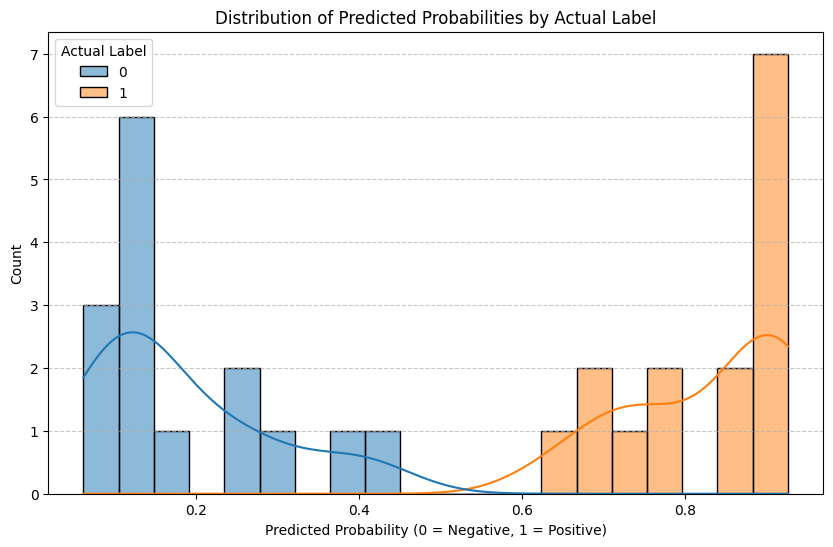

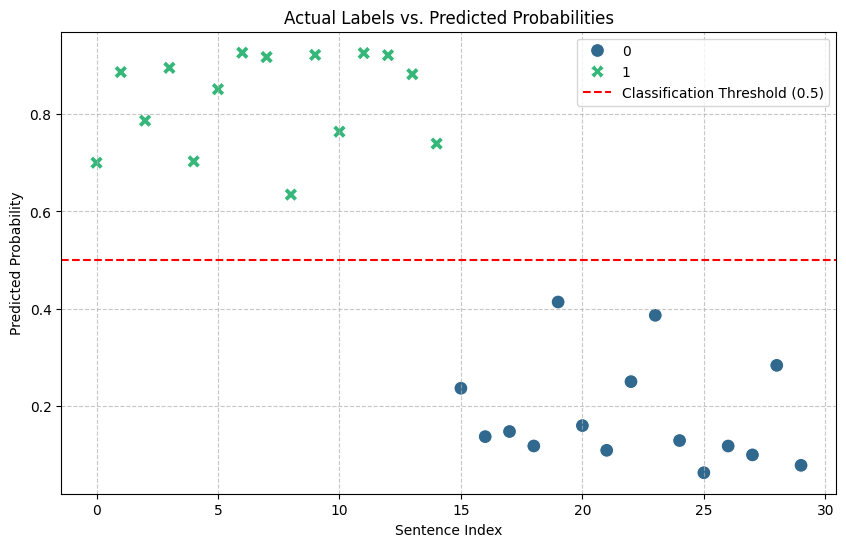

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier plotting
results_df = pd.DataFrame({
    'Actual Label': y,
    'Predicted Probability': predictions.flatten()
})

plt.figure(figsize=(10, 6))
sns.histplot(data=results_df, x='Predicted Probability', hue='Actual Label', kde=True, bins=20)
plt.title('Distribution of Predicted Probabilities by Actual Label')
plt.xlabel('Predicted Probability (0 = Negative, 1 = Positive)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x=results_df.index, y='Predicted Probability', hue='Actual Label', palette='viridis', style='Actual Label', s=100)
plt.axhline(y=0.5, color='r', linestyle='--', label='Classification Threshold (0.5)')
plt.title('Actual Labels vs. Predicted Probabilities')
plt.xlabel('Sentence Index')
plt.ylabel('Predicted Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


```markdown
## Real-time Prediction for New Data

You can use the trained model to predict the sentiment of new sentences. Enter a sentence below to see its predicted sentiment.
```

In [23]:
# Function to predict sentiment for a new sentence
def predict_sentiment(text):
    # Tokenize the input text
    new_seq = tok.texts_to_sequences([text])
    # Pad the sequence to the same maxlen as training data
    padded_new_seq = pad_sequences(new_seq, maxlen=maxlen, padding='post')
    # Get the prediction (probability)
    prediction = model.predict(padded_new_seq)[0][0]

    print(f"\nInput Sentence: '{text}'")
    print(f"Predicted Probability of Positive Sentiment: {prediction:.4f}")

    # Classify based on a threshold (e.g., 0.5)
    if prediction >= 0.5:
        print("Sentiment: Positive")
    else:
        print("Sentiment: Negative")

# Example usage with a user-given sentence
user_sentence = 'This is good for you' # @param {type:"string"}
predict_sentiment(user_sentence)

user_sentence_2 = 'love the movie' # @param {type:"string"}
predict_sentiment(user_sentence_2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Input Sentence: 'This is good for you'
Predicted Probability of Positive Sentiment: 0.5771
Sentiment: Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Input Sentence: 'love the movie'
Predicted Probability of Positive Sentiment: 0.7043
Sentiment: Positive
